**First comparison: MLP vs CNN on regular grids**

In this example, a heat diffusion process is considered, on the fixed segment $[0,1]$, which is discretized with a fixed number of points.

For the training, one of these points is selected as the source term. The goal is to predict the temperature profile (a gaussian shape, centered in this selected point). Two models are considered: a MLP, which is given as input the heat source (as a one-hot vector), and the whole position field, and a CNN, with only the one-hot heat source as input to guarantee translation equivariance.

Both models are trained to fit the heat profile. Once they are trained, they are evaluated on another heat source. The CNN has translation equivariance properties, which ensures correct generalization capacities. The model learns the diffusion process in itself, rather than a single solution. The MLP, on the other hand, feats the training data accurately, but is not able to generalize to another case.

![An illustration of the considered geometry and sampled nodes. The heat source is shown in green, the other sampled nodes are in red.](figures/rectangle_regular.png){#fig-rectangle_regular}

In [1]:
#| include: false
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse

c:\Users\chenaudm\Miniconda3\envs\PyG\lib\site-packages\torch_geometric\typing.py:72: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] La procédure spécifiée est introuvable
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\chenaudm\Miniconda3\envs\PyG\lib\site-packages\torch_geometric\typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] La procédure spécifiée est introuvable
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
# ============================================================================
# DATA GENERATION: One-hot source locations, Gaussian temperature profiles
# ============================================================================

def create_one_hot_source(n_points, source_idx):
    """Create one-hot vector with 1 at source location"""
    vec = np.zeros(n_points)
    vec[source_idx] = 1.0
    return vec

def generate_gaussian_profile(n_points, source_idx, sigma=0.1):
    """Generate Gaussian temperature profile from point source"""
    x = np.linspace(0, 1, n_points)
    source_x = source_idx / (n_points - 1)  # Convert index to position [0,1]
    return np.exp(-(x - source_x)**2 / (2 * sigma**2))

def create_dataset(n_points=64, train_indices=[16, 32, 48], test_indices=[40]):
    """Create dataset with one-hot source vectors"""
    # Training data
    X_train = np.array([create_one_hot_source(n_points, idx) for idx in train_indices])
    y_train = np.array([generate_gaussian_profile(n_points, idx) for idx in train_indices])
    
    # Test data
    X_test = np.array([create_one_hot_source(n_points, idx) for idx in test_indices])
    y_test = np.array([generate_gaussian_profile(n_points, idx) for idx in test_indices])
    
    return X_train, y_train, X_test, y_test

In [3]:
# ============================================================================
# NEURAL NETWORK MODELS
# ============================================================================

class SpatialMLP(nn.Module):
    """MLP with spatial positions + one-hot vector as input"""
    def __init__(self, n_points=64):
        super(SpatialMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # Takes [x_position, one_hot_value]
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)   # Outputs temperature at that point
        )
        self.n_points = n_points
        # Precompute spatial grid
        x_grid = torch.linspace(0, 1, n_points)
        self.register_buffer('x_grid', x_grid)
    
    def forward(self, x_onehot):
        # x_onehot: [batch, n_points] (one-hot source vectors)
        batch_size = x_onehot.shape[0]
        
        # Create input: for each point, [x_position, one_hot_value]
        x_positions = self.x_grid.unsqueeze(0).expand(batch_size, -1)  # [batch, n_points]
        x_positions = x_positions.unsqueeze(-1)  # [batch, n_points, 1]
        x_onehot_expanded = x_onehot.unsqueeze(-1)  # [batch, n_points, 1]
        
        # Concatenate: [x_position, one_hot_value]
        mlp_input = torch.cat([x_positions, x_onehot_expanded], dim=-1)  # [batch, n_points, 2]
        
        # Reshape for MLP: [batch*n_points, 2]
        mlp_input = mlp_input.view(batch_size * self.n_points, 2)
        
        # Process through MLP
        out = self.net(mlp_input)  # [batch*n_points, 1]
        
        # Reshape back to [batch, n_points]
        return out.view(batch_size, self.n_points)

class SmoothCNN(nn.Module):
    """CNN with only one-hot vector input (translation equivariant)"""
    def __init__(self, n_points=64):
        super(SmoothCNN, self).__init__()
        
        self.conv1 = nn.Conv1d(1, 16, kernel_size=15, padding=7)  # Large kernel
        self.conv2 = nn.Conv1d(16, 16, kernel_size=15, padding=7)
        self.conv3 = nn.Conv1d(16, 1, kernel_size=15, padding=7)
        
        # Tanh activation for smooth outputs
        self.tanh = nn.Tanh()
        
    def forward(self, x):
        # x: [batch, n_points] (one-hot source vectors)
        x = x.unsqueeze(1)  # [batch, 1, n_points]
        
        x = self.tanh(self.conv1(x))
        
        x = self.tanh(self.conv2(x))
        
        # Third conv (linear)
        x = self.conv3(x)
        
        return x.squeeze(1)


In [4]:
# ============================================================================
# TRAINING
# ============================================================================

def train_model(model, X_train, y_train, X_test, y_test, epochs=2000, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses, test_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        predictions = model(X_train)
        loss = criterion(predictions, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = criterion(test_pred, y_test)
            test_losses.append(test_loss.item())
        
        if ((epoch + 1) % 500 == 0):
            print(f"Epoch {epoch+1:4d} | Train: {loss.item():.2e} | Test: {test_loss.item():.2e}")
    
    return train_losses, test_losses

For the first experiment, we train the models on a single heat source, located at $x = 0.5$, and we evaluate them for a different source term, at $x = 0.25$.

In [5]:
#| include: false

# ============================================================================
# EXPERIMENT 1: 1 TRAINING CASE
# ============================================================================

# Parameters
n_points = 64
train_indices = [32]          # Source at 0.5
test_indices = [16]           # Source at 0.25 (unseen)

# Create dataset
X_train, y_train, X_test, y_test = create_dataset(n_points, train_indices, test_indices)

# Convert to tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)


print("Training MLP...")
mlp = SpatialMLP(n_points).to(device)
mlp_train_loss, mlp_test_loss = train_model(mlp, X_train_tensor, y_train_tensor, 
                                            X_test_tensor, y_test_tensor, epochs=2500, lr=0.001)

print("\nTraining CNN...")
cnn = SmoothCNN(n_points).to(device)
cnn_train_loss, cnn_test_loss = train_model(cnn, X_train_tensor, y_train_tensor, 
                                            X_test_tensor, y_test_tensor, epochs=2500, lr=0.001)


Training MLP...
Epoch  500 | Train: 1.27e-03 | Test: 2.55e-01
Epoch 1000 | Train: 3.49e-05 | Test: 2.66e-01
Epoch 1500 | Train: 3.21e-06 | Test: 2.67e-01
Epoch 2000 | Train: 1.90e-06 | Test: 2.67e-01
Epoch 2500 | Train: 1.53e-06 | Test: 2.67e-01

Training CNN...
Epoch  500 | Train: 2.70e-06 | Test: 8.78e-04
Epoch 1000 | Train: 5.10e-07 | Test: 8.65e-04
Epoch 1500 | Train: 1.05e-07 | Test: 8.66e-04
Epoch 2000 | Train: 1.97e-08 | Test: 8.68e-04
Epoch 2500 | Train: 6.82e-06 | Test: 9.15e-04


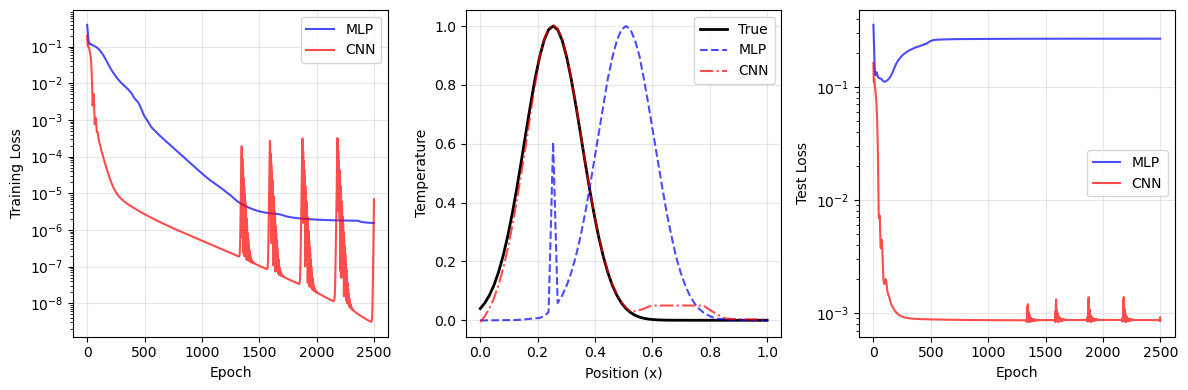

In [6]:
# ============================================================================
# RESULTS VISUALIZATION
# ============================================================================

mlp.eval()
cnn.eval()

with torch.no_grad():
    mlp_pred = mlp(X_test_tensor).cpu().numpy()[0]
    cnn_pred = cnn(X_test_tensor).cpu().numpy()[0]

true_profile = y_test[0]
x = np.linspace(0, 1, n_points)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Training curves
axes[0].plot(mlp_train_loss, 'b-', alpha=0.7, label='MLP')
axes[0].plot(cnn_train_loss, 'r-', alpha=0.7, label='CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Test predictions
axes[1].plot(x, true_profile, 'k-', label='True', linewidth=2)
axes[1].plot(x, mlp_pred, 'b--', label='MLP', alpha=0.7)
axes[1].plot(x, cnn_pred, 'r-.', label='CNN', alpha=0.7)
axes[1].set_xlabel('Position (x)')
axes[1].set_ylabel('Temperature')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test errors
axes[2].plot(mlp_test_loss, 'b-', alpha=0.7, label='MLP')
axes[2].plot(cnn_test_loss, 'r-', alpha=0.7, label='CNN')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Test Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [7]:
#| include: false

mlp_error = np.mean((mlp_pred - true_profile)**2)
cnn_error = np.mean((cnn_pred - true_profile)**2)

print(f"\nFinal Test Errors:")
print(f"MLP (with spatial positions): {mlp_error:.2e}")
print(f"CNN (one-hot only): {cnn_error:.2e}")


Final Test Errors:
MLP (with spatial positions): 2.67e-01
CNN (one-hot only): 9.15e-04


We see that the MLP is not able to generalize, it has learned a single instance of the solution, rather than the correct diffusion process. Because of its inductive biases and correct input selection, the CNN generalizes well.

Now, we extend the training base, with 3 training cases, and sources at different locations.

In [8]:
#| include: false

# ============================================================================
# EXPERIMENT 2: 3 TRAINING CASES
# ============================================================================

# Parameters
n_points = 64
train_indices = [16, 32, 48]  # Sources at 0.25, 0.5, 0.75
test_indices = [40]           # Source at 0.625 (unseen)

# Create dataset
X_train, y_train, X_test, y_test = create_dataset(n_points, train_indices, test_indices)

# Convert to tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)


print("Training MLP...")
mlp = SpatialMLP(n_points).to(device)
mlp_train_loss, mlp_test_loss = train_model(mlp, X_train_tensor, y_train_tensor, 
                                            X_test_tensor, y_test_tensor, epochs=2500, lr=0.001)

print("\nTraining CNN...")
cnn = SmoothCNN(n_points).to(device)
cnn_train_loss, cnn_test_loss = train_model(cnn, X_train_tensor, y_train_tensor, 
                                            X_test_tensor, y_test_tensor, epochs=2500, lr=0.001)


Training MLP...
Epoch  500 | Train: 9.38e-02 | Test: 8.03e-02
Epoch 1000 | Train: 9.37e-02 | Test: 8.11e-02
Epoch 1500 | Train: 9.37e-02 | Test: 8.16e-02
Epoch 2000 | Train: 9.35e-02 | Test: 8.15e-02
Epoch 2500 | Train: 9.34e-02 | Test: 8.18e-02

Training CNN...
Epoch  500 | Train: 9.38e-06 | Test: 1.28e-05
Epoch 1000 | Train: 2.27e-06 | Test: 2.87e-06
Epoch 1500 | Train: 6.81e-07 | Test: 9.35e-07
Epoch 2000 | Train: 2.86e-07 | Test: 4.63e-07
Epoch 2500 | Train: 1.26e-05 | Test: 4.08e-05


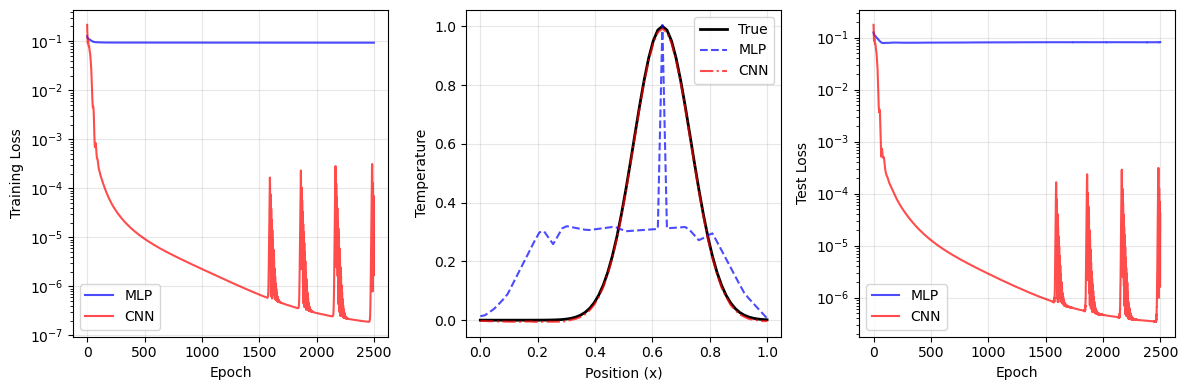

In [9]:
# ============================================================================
# RESULTS VISUALIZATION
# ============================================================================

mlp.eval()
cnn.eval()

with torch.no_grad():
    mlp_pred = mlp(X_test_tensor).cpu().numpy()[0]
    cnn_pred = cnn(X_test_tensor).cpu().numpy()[0]

true_profile = y_test[0]
x = np.linspace(0, 1, n_points)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Training curves
axes[0].plot(mlp_train_loss, 'b-', alpha=0.7, label='MLP')
axes[0].plot(cnn_train_loss, 'r-', alpha=0.7, label='CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Test predictions
axes[1].plot(x, true_profile, 'k-', label='True', linewidth=2)
axes[1].plot(x, mlp_pred, 'b--', label='MLP', alpha=0.7)
axes[1].plot(x, cnn_pred, 'r-.', label='CNN', alpha=0.7)
axes[1].set_xlabel('Position (x)')
axes[1].set_ylabel('Temperature')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test errors
axes[2].plot(mlp_test_loss, 'b-', alpha=0.7, label='MLP')
axes[2].plot(cnn_test_loss, 'r-', alpha=0.7, label='CNN')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Test Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [10]:
#| include: false

mlp_error = np.mean((mlp_pred - true_profile)**2)
cnn_error = np.mean((cnn_pred - true_profile)**2)

print(f"\nFinal Test Errors:")
print(f"MLP (with spatial positions): {mlp_error:.2e}")
print(f"CNN (one-hot only): {cnn_error:.2e}")


Final Test Errors:
MLP (with spatial positions): 8.18e-02
CNN (one-hot only): 4.08e-05


Once again, the MLP is not spatially aware, it cannot capture the diffusion process. Instead, it predicts an average field, which is its best guess given its inputs. The CNN benefits from the added training cases, and predicts the diffusion precisely, even for the unseen case.

**Extension to irregular grids**

Now we extend the case to irregular grids, with non-uniformly spaced data points. In this setting, CNNs are less suitable, and necessitate an additional step of positional encoding before being applied. GNNs can naturally deal with these irregular settings. We will now compare these two models. We train them on 20 cases, and evaluated them on 5 unseen ones.

![Considered geometry, with unevenly-spaced sample nodes. The heat source is shown in green, the other sampled nodes are in red.](figures/rectangle_unregular.png){#fig-rectangle_unregular}

In [11]:
# ============================================================================
# CREATE SINGLE IRREGULAR GRID WITH DISTANCE FEATURES
# ============================================================================

def create_irregular_grid(n_points=64):
    """Create a single irregular grid with varying density"""
    # Create base points with varying density
    base = np.linspace(0, 1, n_points//2)
    # Add more points in the middle
    extra = np.random.uniform(0.4, 0.6, n_points//2)
    points = np.concatenate([base, extra])
    points.sort()
    return points

def create_dataset_on_grid(x_grid, n_train=10, n_test=3, sigma=0.1):
    """Create dataset on the given grid with distance features"""
    # Generate random source positions
    train_positions = np.random.uniform(0.1, 0.9, n_train)
    test_positions = np.random.uniform(0.1, 0.9, n_test)
    
    # Training data
    X_train = []
    y_train = []
    for pos in train_positions:
        # Input: distance from each point to source
        distances = np.abs(x_grid - pos)
        X_train.append(distances)
        # Output: Gaussian
        y_train.append(np.exp(-distances**2 / (2 * sigma**2)))
    
    # Test data
    X_test = []
    y_test = []
    for pos in test_positions:
        distances = np.abs(x_grid - pos)
        X_test.append(distances)
        y_test.append(np.exp(-distances**2 / (2 * sigma**2)))
    
    return (np.array(X_train), np.array(y_train), 
            np.array(X_test), np.array(y_test), 
            train_positions, test_positions)

In [12]:
#| include: false

# ============================================================================
# EXPERIMENT SETUP
# ============================================================================

# Create single irregular grid
n_points = 64
x_grid = create_irregular_grid(n_points)

# Create dataset with distance features
n_train = 20
n_test = 5
X_train, y_train, X_test, y_test, train_positions, test_positions = create_dataset_on_grid(
    x_grid, n_train=n_train, n_test=n_test, sigma=0.1
)

print(f"\nIrregular grid with {n_points} points")
print(f"Training samples: {n_train}")
print(f"Test samples: {n_test}")

# Prepare data for both models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# CNN data
X_train_cnn = torch.FloatTensor(X_train).to(device)
y_train_cnn = torch.FloatTensor(y_train).to(device)
X_test_cnn = torch.FloatTensor(X_test).to(device)
y_test_cnn = torch.FloatTensor(y_test).to(device)

# Create adjacency matrix for GNN based knn
def create_knn_graph(x_grid, k=5):
    """Create k-NN graph from irregular grid points"""
    n_points = len(x_grid)
    edges = []
    
    for i in range(n_points):
        # Calculate distances to all other points
        distances = np.abs(x_grid - x_grid[i])
        
        # Get k nearest neighbors (excluding self)
        nearest = np.argsort(distances)[1:k+1]
        
        for j in nearest:
            edges.append([i, j])
            edges.append([j, i])  # Undirected
    
    return torch.tensor(edges, dtype=torch.long).t()


edge_index = create_knn_graph(x_grid, k=5)
edge_index = edge_index.to(device)


# GNN data
train_graphs = []
for distances, temps in zip(X_train, y_train):
    node_features = torch.FloatTensor(distances).unsqueeze(1)
    graph = Data(x=node_features, edge_index=edge_index, 
                 y=torch.FloatTensor(temps).unsqueeze(1))
    train_graphs.append(graph)

test_graphs = []
for distances, temps in zip(X_test, y_test):
    node_features = torch.FloatTensor(distances).unsqueeze(1)
    graph = Data(x=node_features, edge_index=edge_index,
                 y=torch.FloatTensor(temps).unsqueeze(1))
    test_graphs.append(graph)

train_loader = DataLoader(train_graphs, batch_size=4, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=1, shuffle=False)



Irregular grid with 64 points
Training samples: 20
Test samples: 5


In [13]:
# ============================================================================
# MODELS DEFINITION
# ============================================================================

### CNN:

class IrregularCNN(nn.Module):
    """CNN with adaptive pooling for irregular grids"""
    def __init__(self, n_points=64):
        super(IrregularCNN, self).__init__()
        
        # Input: distance to source [batch, 1, n_points]
        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(32, 1, kernel_size=3, padding=1)
        
        # Adaptive layers to handle any input size
        self.adaptive_pool = nn.AdaptiveAvgPool1d(n_points)
        
        # Non-linearities
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()
        
        # BatchNorm for stability
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(32)
        
    def forward(self, x):
        # x: [batch, n_points] -> [batch, 1, n_points]
        x = x.unsqueeze(1)
        
        # Conv block 1
        x = self.tanh(self.bn1(self.conv1(x)))
        
        # Conv block 2
        x = self.tanh(self.bn2(self.conv2(x)))
        
        # Conv block 3
        x = self.tanh(self.bn3(self.conv3(x)))
        
        # Final conv
        x = self.conv4(x)
        
        # Ensure correct output size
        x = self.adaptive_pool(x)
        
        return x.squeeze(1)

### GNN:

class EdgeConv(MessagePassing):
    """Edge convolution that uses edge features"""
    def __init__(self, in_channels, out_channels):
        super(EdgeConv, self).__init__(aggr='mean')
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )
        
    def forward(self, x, edge_index, edge_attr=None):
        return self.propagate(edge_index, x=x)
    
    def message(self, x_i, x_j):
        # Concatenate source and target node features
        return self.mlp(torch.cat([x_i, x_j], dim=-1))

class GNN(nn.Module):
    """GNN with edge features and residual connections"""
    def __init__(self, hidden_dim=32):
        super(GNN, self).__init__()
        
        # Input: distance to source [batch, 1]
        self.input_proj = nn.Linear(1, hidden_dim)
        
        # EdgeConv layers
        self.conv1 = EdgeConv(hidden_dim, hidden_dim)
        self.conv2 = EdgeConv(hidden_dim, hidden_dim)
        self.conv3 = EdgeConv(hidden_dim, hidden_dim)
        
        # Output layer
        self.output = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Residual connections
        self.res1 = nn.Linear(hidden_dim, hidden_dim)
        self.res2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Normalizations
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.norm3 = nn.LayerNorm(hidden_dim)
        
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Project input
        x = self.input_proj(x)
        
        # Layer 1 with residual
        identity = x
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = x + self.res1(identity)
        x = torch.tanh(x)
        
        # Layer 2 with residual
        identity = x
        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = x + self.res2(identity)
        x = torch.tanh(x)
        
        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = torch.tanh(x)
        
        # Output
        x = self.output(x)
        
        return x.squeeze(-1)

In [14]:
# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

### CNN:

def train_cnn(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)
    criterion = nn.MSELoss()
    
    train_losses, test_losses = [], []
    best_loss = float('inf')
    patience_counter = 0
    patience = 100
    
    print("\nTraining CNN...")
    print("-" * 40)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        predictions = model(X_train)
        loss = criterion(predictions, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = criterion(test_pred, y_test)
            test_losses.append(test_loss.item())
        
        scheduler.step(test_loss)
        
        # Early stopping
        if test_loss.item() < best_loss:
            best_loss = test_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), 'best_cnn.pt')
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
        
        if ((epoch + 1) % 500 == 0):
            print(f"Epoch {epoch+1:4d} | Train: {loss.item():.4e} | Test: {test_loss.item():.4e}")
    
    # Load best model
    model.load_state_dict(torch.load('best_cnn.pt'))
    return train_losses, test_losses

### GNN:

def train_gnn(model, train_loader, test_loader, epochs=500, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)
    criterion = nn.MSELoss()
    
    train_losses, test_losses = [], []
    best_loss = float('inf')
    patience_counter = 0
    patience = 500
    
    print("\nTraining GNN...")
    print("-" * 40)
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            
            predictions = model(data)
            loss = criterion(predictions, data.y.squeeze(-1))
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Test
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                test_pred = model(data)
                test_loss = criterion(test_pred, data.y.squeeze(-1))
                total_test_loss += test_loss.item()
        
        avg_test_loss = total_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        scheduler.step(avg_test_loss)
        
        # Early stopping
        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_gnn.pt')
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
        
        if ((epoch + 1) % 500 == 0):
            print(f"Epoch {epoch+1:4d} | Train: {avg_train_loss:.4e} | Test: {avg_test_loss:.4e}")
    
    # Load best model
    model.load_state_dict(torch.load('best_gnn.pt'))
    return train_losses, test_losses

In [15]:
#| include: false

# ============================================================================
# START TRAINING
# ============================================================================

torch.manual_seed(42)
np.random.seed(42)
# Train models
cnn = IrregularCNN(n_points=n_points).to(device)
cnn_train_loss, cnn_test_loss = train_cnn(
    cnn, X_train_cnn, y_train_cnn, X_test_cnn, y_test_cnn,
    epochs=2000, lr=0.002
)

gnn = GNN(hidden_dim=32).to(device)
gnn_train_loss, gnn_test_loss = train_gnn(
    gnn, train_loader, test_loader,
    epochs=2000, lr=0.001
)


Training CNN...
----------------------------------------
Epoch  500 | Train: 1.6034e-04 | Test: 1.7015e-04
Epoch 1000 | Train: 7.7478e-05 | Test: 9.3551e-05
Epoch 1500 | Train: 5.7421e-05 | Test: 7.1834e-05
Epoch 2000 | Train: 4.9276e-05 | Test: 6.3559e-05

Training GNN...
----------------------------------------
Epoch  500 | Train: 3.3383e-06 | Test: 4.1968e-06
Epoch 1000 | Train: 2.5920e-06 | Test: 3.2932e-06
Epoch 1500 | Train: 2.2089e-06 | Test: 3.0664e-06
Epoch 2000 | Train: 1.7828e-06 | Test: 2.5001e-06


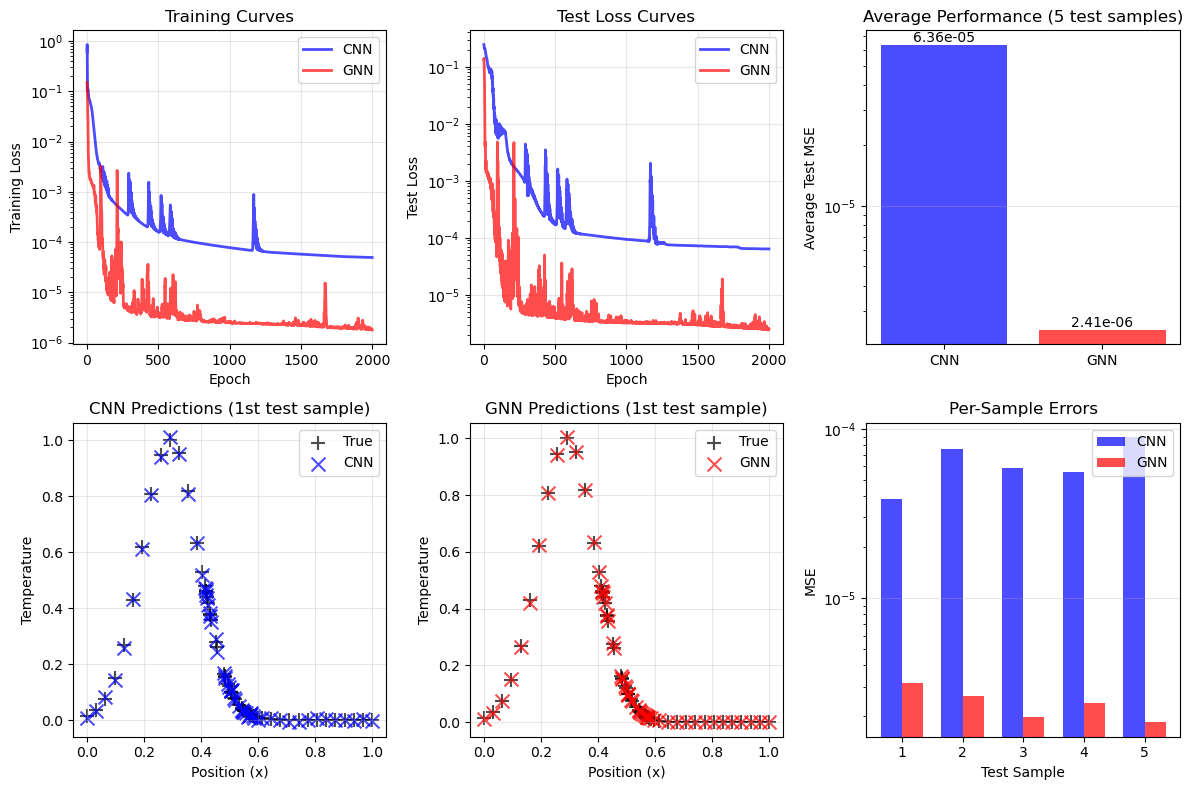

In [16]:
# ============================================================================
# RESULTS VISUALIZATION
# ============================================================================

cnn.eval()
gnn.eval()

# Get predictions for first test sample
with torch.no_grad():
    cnn_pred = cnn(X_test_cnn[:1]).cpu().numpy()[0]
    test_data = test_graphs[0].to(device)
    gnn_pred = gnn(test_data).cpu().numpy()

true_profile = y_test[0]

# Calculate average errors
cnn_errors = []
gnn_errors = []

with torch.no_grad():
    for i in range(len(X_test)):
        # CNN error
        cnn_pred_i = cnn(X_test_cnn[i:i+1]).cpu().numpy()[0]
        cnn_error = np.mean((cnn_pred_i - y_test[i])**2)
        cnn_errors.append(cnn_error)
        
        # GNN error
        test_data_i = test_graphs[i].to(device)
        gnn_pred_i = gnn(test_data_i).cpu().numpy()
        gnn_error = np.mean((gnn_pred_i - y_test[i])**2)
        gnn_errors.append(gnn_error)

cnn_avg_error = np.mean(cnn_errors)
gnn_avg_error = np.mean(gnn_errors)

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot 1: Training curves
axes[0, 0].plot(cnn_train_loss, 'b-', alpha=0.7, label='CNN', linewidth=2)
axes[0, 0].plot(gnn_train_loss, 'r-', alpha=0.7, label='GNN', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Plot 2: Test errors
axes[0, 1].plot(cnn_test_loss, 'b-', alpha=0.7, label='CNN', linewidth=2)
axes[0, 1].plot(gnn_test_loss, 'r-', alpha=0.7, label='GNN', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_yscale('log')

# Plot 3: Error comparison
models = ['CNN', 'GNN']
errors = [cnn_avg_error, gnn_avg_error]
colors = ['blue', 'red']

bars = axes[0, 2].bar(models, errors, color=colors, alpha=0.7)
axes[0, 2].set_ylabel('Average Test MSE')
axes[0, 2].set_title(f'Average Performance ({n_test} test samples)')
axes[0, 2].grid(True, alpha=0.3, axis='y')
axes[0, 2].set_yscale('log')
# Add error values
for bar, error in zip(bars, errors):
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                f'{error:.2e}', ha='center', va='bottom', fontsize=10)
# Plot 4: CNN predictions
axes[1, 0].scatter(x_grid, true_profile, c='k', s=100, label='True', alpha=0.7, marker = '+')
axes[1, 0].scatter(x_grid, cnn_pred, c='b', s=100, label='CNN', alpha=0.7, marker = 'x')
axes[1, 0].set_xlabel('Position (x)')
axes[1, 0].set_ylabel('Temperature')
axes[1, 0].set_title('CNN Predictions (1st test sample)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: GNN predictions
axes[1, 1].scatter(x_grid, true_profile, c='k', s=100, label='True', alpha=0.7, marker = '+')
axes[1, 1].scatter(x_grid, gnn_pred, c='r', s=100, label='GNN', alpha=0.7, marker = 'x')
axes[1, 1].set_xlabel('Position (x)')
axes[1, 1].set_ylabel('Temperature')
axes[1, 1].set_title('GNN Predictions (1st test sample)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Error comparison
sample_indices = range(1, n_test + 1)
width = 0.35
x = np.arange(len(sample_indices))
axes[1,2].bar(x - width/2, cnn_errors, width, label='CNN', alpha=0.7, color='blue')
axes[1,2].bar(x + width/2, gnn_errors, width, label='GNN', alpha=0.7, color='red')
axes[1,2].set_xlabel('Test Sample')
axes[1,2].set_ylabel('MSE')
axes[1,2].set_title('Per-Sample Errors')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(sample_indices)
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')
axes[1,2].set_yscale('log')



plt.tight_layout()
plt.show()


In [17]:
#| include: false

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)

print(f"\nAverage Test MSE over {n_test} samples:")
print(f"CNN: {cnn_avg_error:.4e}")
print(f"GNN: {gnn_avg_error:.4e}")

def count_parameters(model):
    """Count total trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_params = count_parameters(cnn)
gnn_params = count_parameters(gnn)

print(f"\nNumber of trainable parameters:")
print(f"CNN: {cnn_params:,} parameters")
print(f"GNN: {gnn_params:,} parameters")


FINAL RESULTS

Average Test MSE over 5 samples:
CNN: 6.3559e-05
GNN: 2.4081e-06

Number of trainable parameters:
CNN: 17,089 parameters
GNN: 12,865 parameters


With a test error smaller by more than one order of magnitude, the GNN can handle irregular grid points very well, and the performance gap with a CNN is clear, even for this simple setting. Note that this gap is not due to the model's complexity, since the GNN has fewer trainable parameters.